In [0]:
# ==========================================
# Load Sample Dataset
# ==========================================

SAMPLE_PATH = "/Volumes/project/default/data/sample100k/"

sample_df = spark.read.parquet(SAMPLE_PATH)

print("Rows :", sample_df.count())
print("Columns :", len(sample_df.columns))

display(sample_df.limit(5))

Rows : 100000
Columns : 27


parent_asin,asin,user_id,review_rating,review_title,review_text,helpful_vote,verified_purchase,review_images,product_title,average_rating,rating_number,price,store,main_category,categories,features,description,details,product_images,videos,review_timestamp,year,month,day,quarter,week
B0BYH9WTKC,B0BTY52TS3,AGHZY22RKZM5R22XD22V2YP5ANCA,4.0,They fit okay.,"I wish these were silicone or rubber on both sides. I haven't tried to cl an any drips off yet, but imagine the top being fabric makes it harder to clean. The ice dispenser on my refrigerator is black, so I couldn't get a good picture. The small one fits toward the outside edge of the compartment, but doesn't go all the way back. That is fine though because the drips happen at the front of the compartment. It does stay in place pretty well. Overall, they are okay, but not wonderful.",0,false,"List(List(IMAGE, https://m.media-amazon.com/images/I/81i0sjxu43L._SL1600_.jpg, https://m.media-amazon.com/images/I/81i0sjxu43L._SL800_.jpg, https://m.media-amazon.com/images/I/81i0sjxu43L._SL256_.jpg))","2 Pack Refrigerator Water Catcher with Magnets, Upgraded Non-Slip Magnet Design Absorbent Pad for Refrigerator Drip Tray, Quick Dry Water Drip Pads, Rectangular (2 Small Size)",4.0,17,15.93,Haldane,Amazon Home,"List(Appliances, Parts & Accessories, Range Parts & Accessories, Drip Pans)","List(【Ultimate Protection for Surfaces】Enjoy maximum protection from Ice, water and stains of all sizes; make you no need to wipe the sink fridge tray every time after using refrigerator drip catcher., 【New Upgraded Non-Slip Magnet Design】Suction magnets are added to the back of the refrigerator drip tray to help keep them in place and prevent it from falling out every time you open and close the refrigerator. 3 times the weight of other refrigerator water tray., 【Super Absorbent & Fast Drying】The absorbent pad is made of microfiber material and sponge core,100 percent waterproof bottom layer.Our frigerator drip catcher is the best solution for your water stains., 【Fit for Most Refrigerators Water Tray】The water drip pads is specially designed for the refrigerator drip tray and is suitable for most water trays., 【Easy Clean】Fully machine washable or simply hand wash and dry. WARM TIPS:Please check your tray’s size before you buy, because not all SAMSUNG,LG,GE,WHIRLPOOL are the same size.)",List(),"Map(Best Sellers Rank -> {""Tools & Home Improvement"": 482644, ""Range Replacement Drip Pans"": 332}, Product Dimensions -> 2.95 x 0.78 x 7.48 inches, Manufacturer -> Haldane, Item Weight -> 4.6 ounces, Date First Available -> February 17, 2023, Country of Origin -> China, Item model number -> RWC09)","List(Map(thumb -> https://m.media-amazon.com/images/I/51V8O+gtSVL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/51V8O+gtSVL._AC_.jpg, variant -> MAIN, hi_res -> https://m.media-amazon.com/images/I/61YCepgomyL._AC_SL1000_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/516AoWfMP0L._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/516AoWfMP0L._AC_.jpg, variant -> PT01, hi_res -> https://m.media-amazon.com/images/I/61wAXgFU+HL._AC_SL1000_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/51C6dZEJcvL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/51C6dZEJcvL._AC_.jpg, variant -> PT02, hi_res -> https://m.media-amazon.com/images/I/61PtjfqhJ6L._AC_SL1000_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/51ptGtslP8L._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/51ptGtslP8L._AC_.jpg, variant -> PT03, hi_res -> https://m.media-amazon.com/images/I/61wVe-TqcsL._AC_SL1000_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/51CG-GiWaUL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/51CG-GiWaUL._AC_.jpg, variant -> PT04, hi_res -> https://m.media-amazon.com/images/I/61MZLOTKIcL._AC_SL1000_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41A6jJcgb8L._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/41A6jJcgb8L._AC_.jpg, variant

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

sample_pd = sample_df.toPandas()

In [0]:
sample_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   parent_asin        100000 non-null  object        
 1   asin               100000 non-null  object        
 2   user_id            100000 non-null  object        
 3   review_rating      100000 non-null  float64       
 4   review_title       100000 non-null  object        
 5   review_text        100000 non-null  object        
 6   helpful_vote       100000 non-null  int64         
 7   verified_purchase  100000 non-null  bool          
 8   review_images      100000 non-null  object        
 9   product_title      100000 non-null  object        
 10  average_rating     100000 non-null  float64       
 11  rating_number      100000 non-null  int64         
 12  price              73596 non-null   float64       
 13  store              99624 non-null   object   

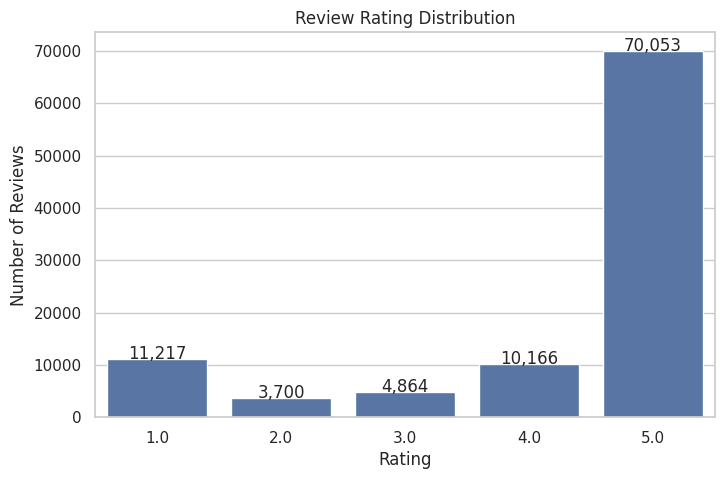

In [0]:
rating = (
    sample_df.groupBy("review_rating")
    .count()
    .orderBy("review_rating")
    .toPandas()
)

plt.figure(figsize=(8,5))
sns.barplot(data=rating,x="review_rating",y="count")

plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i,v in enumerate(rating["count"]):
    plt.text(i,v,f"{v:,}",ha="center")

plt.show()

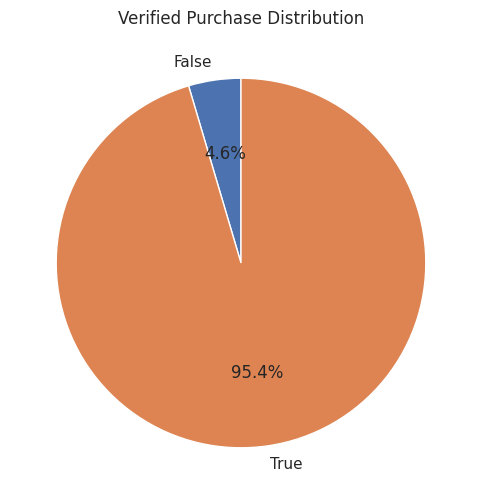

In [0]:
verified = (
    sample_df.groupBy("verified_purchase")
    .count()
    .toPandas()
)

plt.figure(figsize=(6,6))

plt.pie(
    verified["count"],
    labels=verified["verified_purchase"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Verified Purchase Distribution")

plt.show()

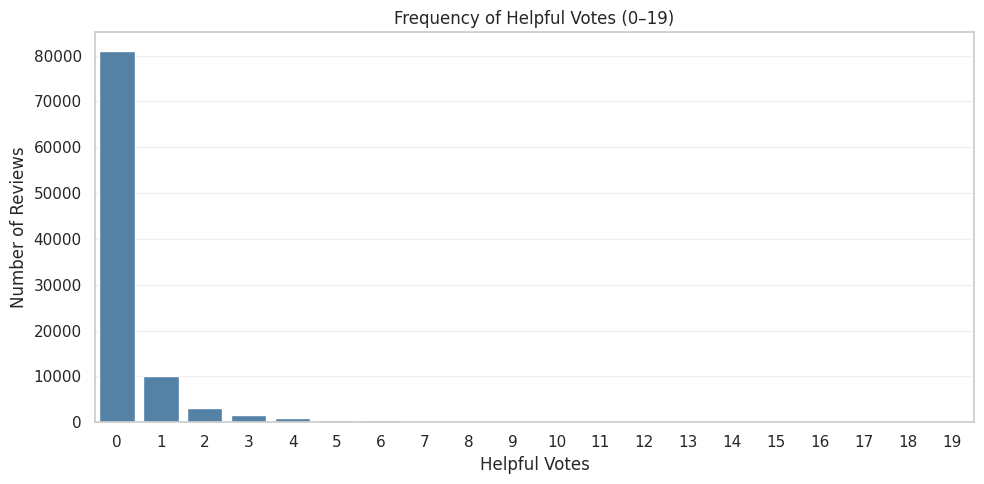

In [0]:
vote_counts = (
    sample_df.groupBy("helpful_vote")
    .count()
    .orderBy("helpful_vote")
    .limit(20)
    .toPandas()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=vote_counts,
    x="helpful_vote",
    y="count",
    color="steelblue"
)

plt.title("Frequency of Helpful Votes (0–19)")
plt.xlabel("Helpful Votes")
plt.ylabel("Number of Reviews")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

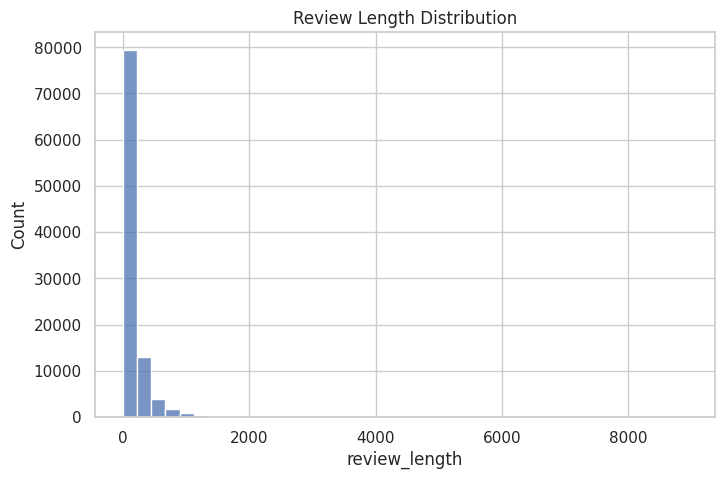

In [0]:
sample_pd["review_length"] = sample_pd["review_text"].fillna("").str.len()

plt.figure(figsize=(8,5))

sns.histplot(
    sample_pd["review_length"],
    bins=40
)

plt.title("Review Length Distribution")

plt.show()

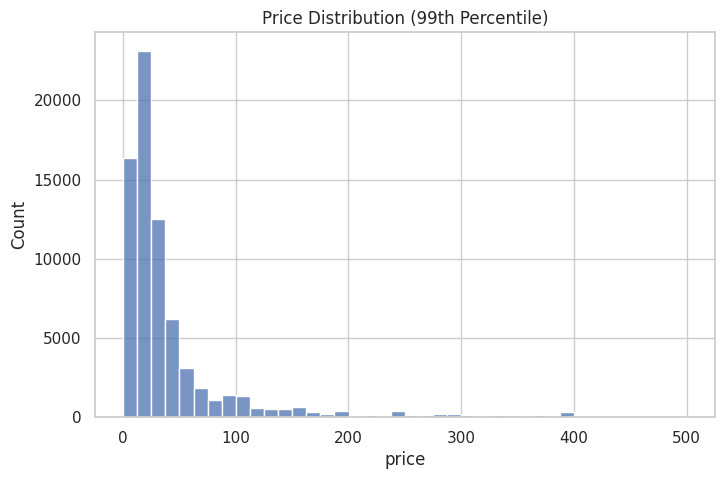

In [0]:
price = sample_pd["price"].dropna()

upper = price.quantile(.99)

price = price[price<=upper]

plt.figure(figsize=(8,5))

sns.histplot(
    price,
    bins=40
)

plt.title("Price Distribution (99th Percentile)")

plt.show()

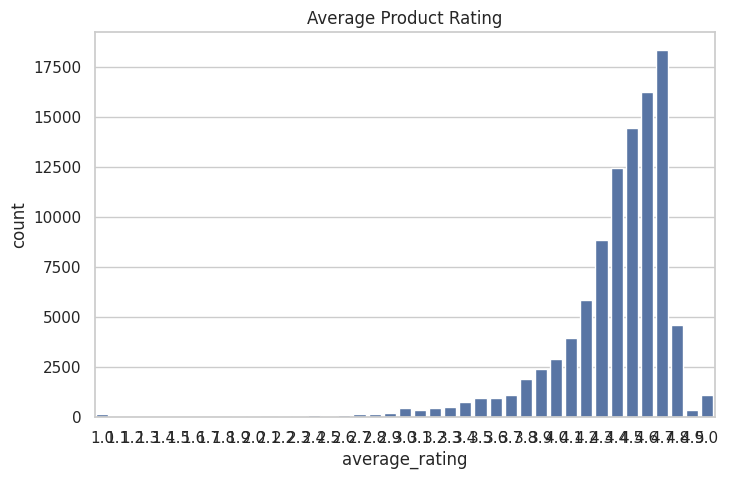

In [0]:
avg_rating = (
    sample_df.groupBy("average_rating")
    .count()
    .orderBy("average_rating")
    .toPandas()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_rating,
    x="average_rating",
    y="count"
)

plt.title("Average Product Rating")

plt.show()

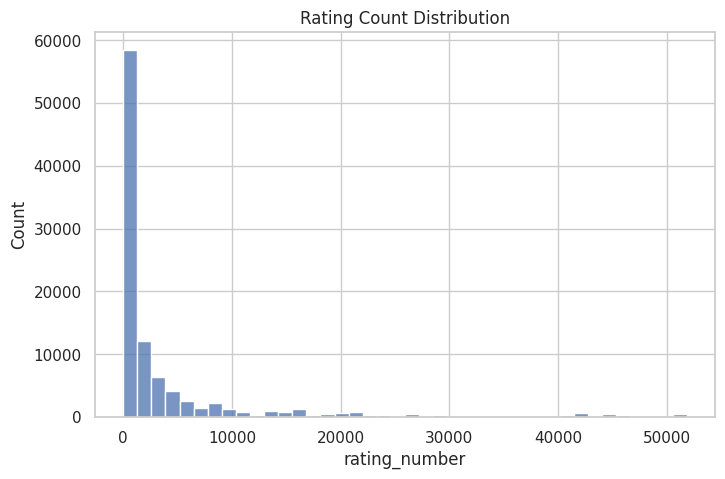

In [0]:
rating_num = sample_pd["rating_number"]

upper = rating_num.quantile(.99)

rating_num = rating_num[rating_num<=upper]

plt.figure(figsize=(8,5))

sns.histplot(
    rating_num,
    bins=40
)

plt.title("Rating Count Distribution")

plt.show()

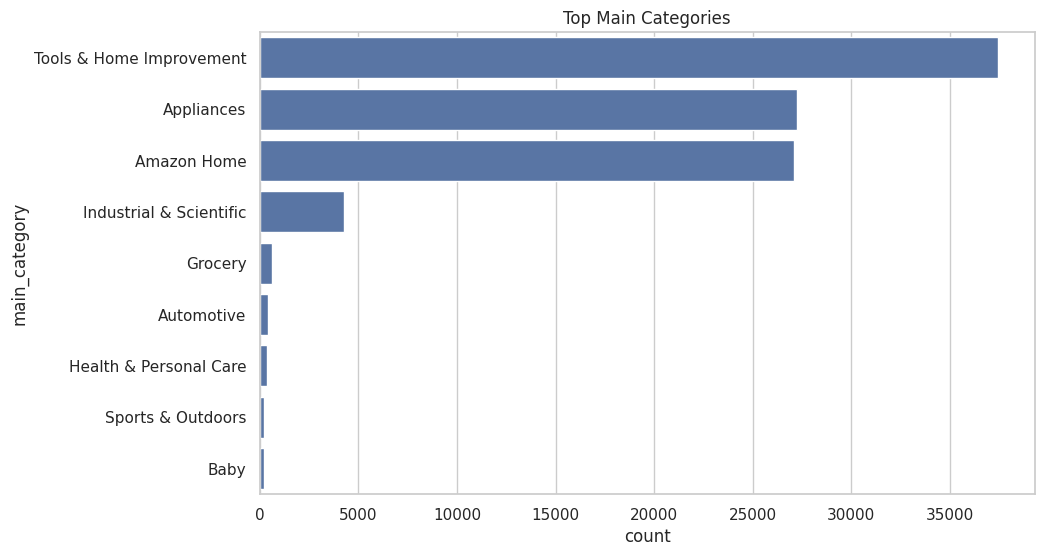

In [0]:
category = (
    sample_df.groupBy("main_category")
    .count()
    .orderBy("count",ascending=False)
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=category,
    y="main_category",
    x="count"
)

plt.title("Top Main Categories")

plt.show()

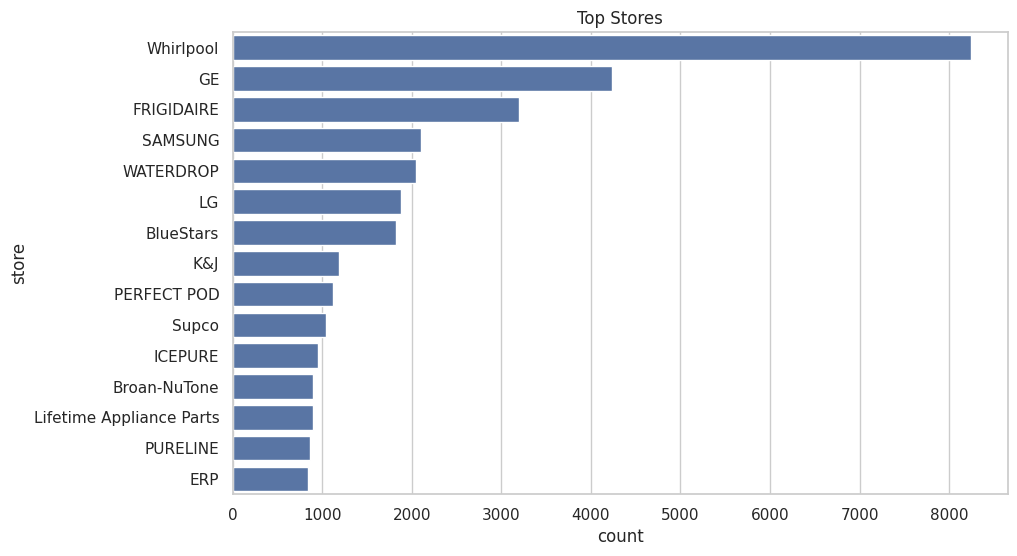

In [0]:
stores = (
    sample_df.groupBy("store")
    .count()
    .orderBy("count",ascending=False)
    .limit(15)
    .toPandas()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=stores,
    y="store",
    x="count"
)

plt.title("Top Stores")

plt.show()

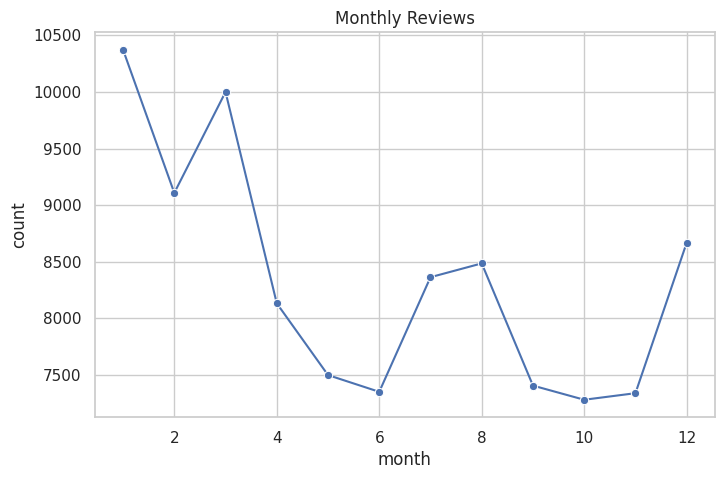

In [0]:
month = (
    sample_df.groupBy("month")
    .count()
    .orderBy("month")
    .toPandas()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=month,
    x="month",
    y="count",
    marker="o"
)

plt.title("Monthly Reviews")

plt.show()

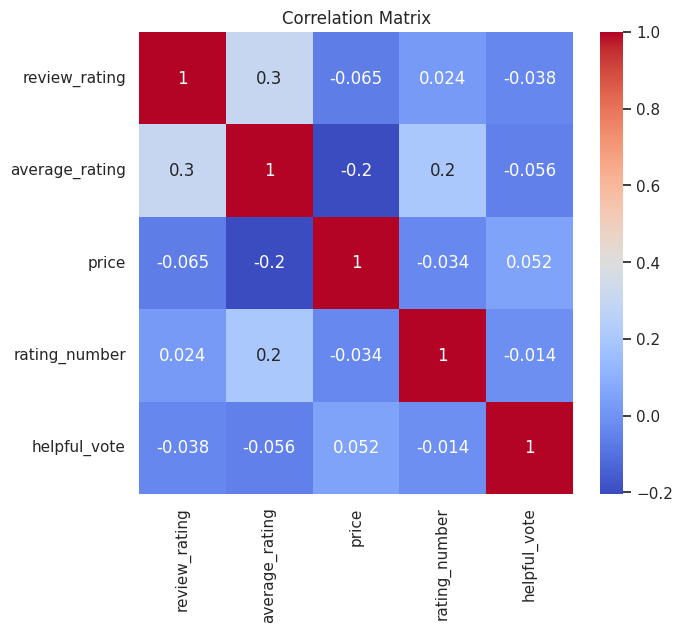

In [0]:
corr = sample_pd[
    [
        "review_rating",
        "average_rating",
        "price",
        "rating_number",
        "helpful_vote"
    ]
].corr()

plt.figure(figsize=(7,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [0]:
%pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.5/547.5 kB 13.8 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


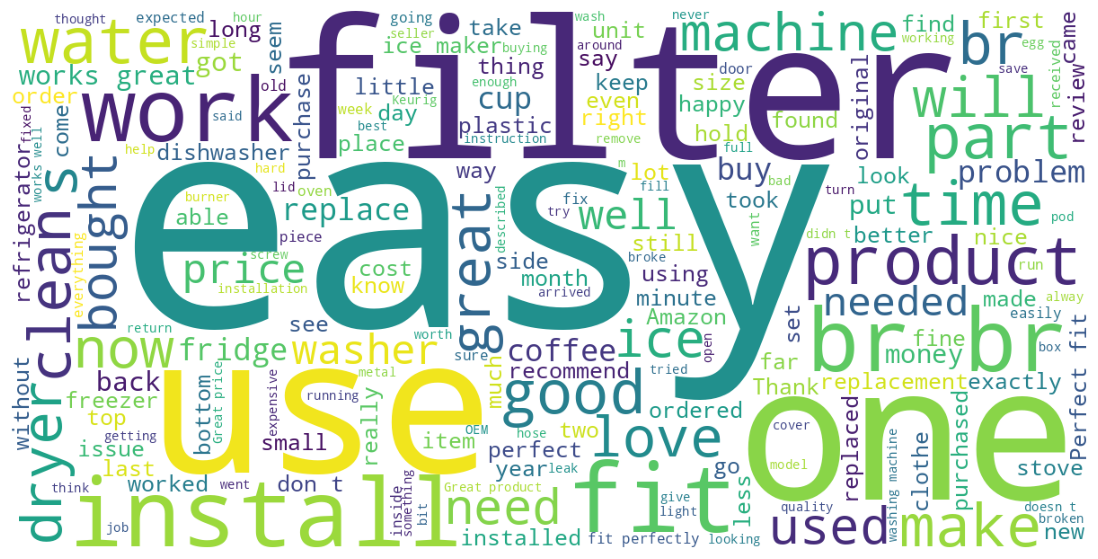

In [0]:
from wordcloud import WordCloud

text = " ".join(sample_pd["review_text"].fillna("").head(50000))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wc)

plt.axis("off")

plt.show()

In [0]:
from pyspark.sql import functions as F

sample_df = (
    sample_df
    .withColumn(
        "sentiment",
        F.when(F.col("review_rating") >= 4, "Positive")
         .when(F.col("review_rating") == 3, "Neutral")
         .otherwise("Negative")
    )
)

/home/spark-029222fe-989c-4b54-a904-ae/.ipykernel/316/command-6990850509215543-3742431221:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


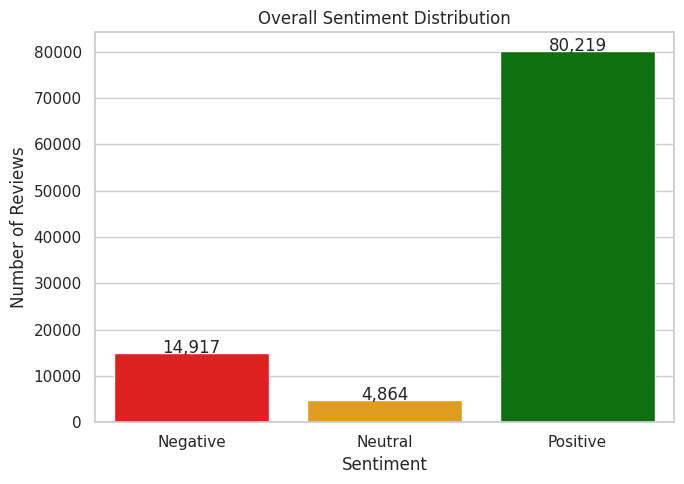

In [0]:
sentiment_df = (
    sample_df
    .groupBy("sentiment")
    .count()
    .orderBy("sentiment")
    .toPandas()
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=sentiment_df,
    x="sentiment",
    y="count",
    palette=["red", "orange", "green"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, v in enumerate(sentiment_df["count"]):
    plt.text(i, v, f"{v:,}", ha="center")

plt.tight_layout()
plt.show()

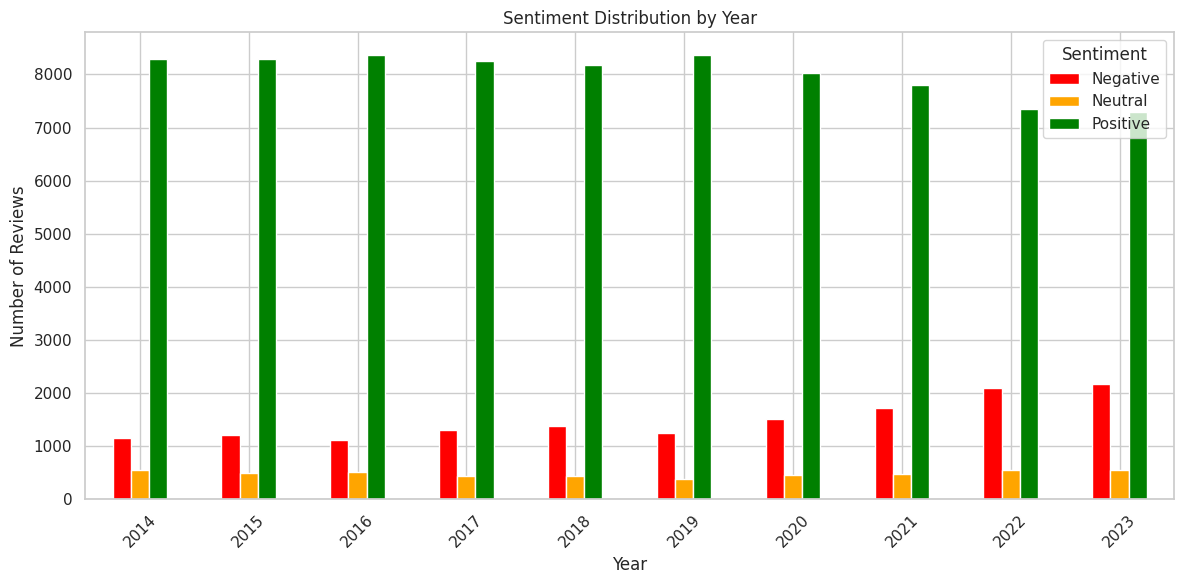

In [0]:
sentiment_year = (
    sample_df
    .groupBy("year", "sentiment")
    .count()
    .orderBy("year")
    .toPandas()
)

pivot_df = sentiment_year.pivot(
    index="year",
    columns="sentiment",
    values="count"
).fillna(0)

pivot_df.plot(
    kind="bar",
    figsize=(12,6),
    color=["red", "orange", "green"]
)

plt.title("Sentiment Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

# Business Insights

### Customer Reviews
- Majority of reviews are 5-star ratings, indicating high customer satisfaction.
- Verified purchases dominate the review dataset.
- Most reviews receive few or no helpful votes, with a small number of highly influential reviews.
- Customers generally write short to medium-length reviews.

### Product Insights
- Product prices are heavily concentrated in the lower price range.
- A small number of premium-priced products exist as outliers.
- Product rating counts are highly skewed, with only a few products receiving very large numbers of ratings.

### Time Trends
- Stratified sampling ensures equal representation from 2014–2023.
- Monthly and quarterly review distributions reveal seasonal customer activity.

### Business Opportunities
- Highly reviewed products can be prioritized for recommendation engines.
- Popular stores contribute significantly to customer engagement.
- Frequently occurring review terms can help identify common customer preferences and issues.